## <span style='color: yellow;'> Import Libraries </span>

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer




## <span style='color: indigo;'> Load Data Set </span>

In [36]:

df = pd.read_excel("_cancer_dataset_uae.xlsx")

# Show basic info
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Patient_ID            10000 non-null  object        
 1   Age                   10000 non-null  int64         
 2   Gender                10000 non-null  object        
 3   Nationality           10000 non-null  object        
 4   Emirate               10000 non-null  object        
 5   Diagnosis_Date        10000 non-null  datetime64[ns]
 6   Cancer_Type           10000 non-null  object        
 7   Cancer_Stage          10000 non-null  object        
 8   Treatment_Type        10000 non-null  object        
 9   Treatment_Start_Date  10000 non-null  datetime64[ns]
 10  Hospital              10000 non-null  object        
 11  Primary_Physician     10000 non-null  object        
 12  Outcome               10000 non-null  object        
 13  Death_Date       

,Patient_ID,Age,Gender,Nationality,Emirate,Diagnosis_Date,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height
0,PAT000001,69,Female,Emirati,Umm Al Quwain,2020-11-30,Liver,II,Radiation,2020-12-04,Sheikh Khalifa Hospital,Dr. VO41,Recovered,NaT,NaN,Non-Smoker,NaN,European,61,157
1,PAT000002,32,Male,Emirati,Umm Al Quwain,2015-10-10,Leukemia,III,Surgery,2015-11-05,Dubai Hospital,Dr. SM31,Recovered,NaT,NaN,Smoker,NaN,South Asian,80,175
2,PAT000003,89,Male,Emirati,Abu Dhabi,2018-02-13,Liver,III,Radiation,2018-08-03,Zayed Military Hospital,Dr. BC7,Under Treatment,NaT,NaN,Non-Smoker,NaN,South Asian,50,175
3,PAT000004,78,Female,Emirati,Abu Dhabi,2022-02-04,Lung,III,Radiation,2022-03-13,Cleveland Clinic Abu Dhabi,Dr. TC14,Recovered,NaT,NaN,Former Smoker,NaN,African,44,155
4,PAT000005,38,Female,Emirati,Fujairah,2019-12-03,Pancreatic,II,Chemotherapy,2020-02-29,Sheikh Khalifa Hospital,Dr. YS37,Recovered,NaT,NaN,Former Smoker,NaN,East Asian,101,160


## <span style='color: blue;'> Basic Data Infomations </span>

In [3]:
df.shape

(10000, 20)

In [17]:
df.describe()

,Age,Diagnosis_Date,Treatment_Start_Date,Death_Date,Weight,Height
count,10000.000000,10000,10000,992,10000.000000,10000.000000
mean,53.539700,2019-08-08 15:31:58.080000,2019-11-05 23:51:38.880000,2020-12-31 22:57:34.838709760,69.550000,169.347500
min,18.000000,2015-01-01 00:00:00,2015-01-07 00:00:00,2015-04-24 00:00:00,18.000000,131.000000
25%,36.000000,2017-04-05 00:00:00,2017-07-05 00:00:00,2018-09-21 00:00:00,60.000000,163.000000
50%,53.000000,2019-08-26 12:00:00,2019-11-24 00:00:00,2020-12-22 00:00:00,70.000000,169.000000
75%,72.000000,2021-11-22 00:00:00,2022-02-18 00:00:00,2023-05-24 12:00:00,80.000000,176.000000
max,89.000000,2024-03-01 00:00:00,2024-08-23 00:00:00,2026-05-15 00:00:00,122.000000,208.000000
std,20.757324,NaN,NaN,NaN,14.933339,10.070118


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Patient_ID            10000 non-null  object        
 1   Age                   10000 non-null  int64         
 2   Gender                10000 non-null  object        
 3   Nationality           10000 non-null  object        
 4   Emirate               10000 non-null  object        
 5   Diagnosis_Date        10000 non-null  datetime64[ns]
 6   Cancer_Type           10000 non-null  object        
 7   Cancer_Stage          10000 non-null  object        
 8   Treatment_Type        10000 non-null  object        
 9   Treatment_Start_Date  10000 non-null  datetime64[ns]
 10  Hospital              10000 non-null  object        
 11  Primary_Physician     10000 non-null  object        
 12  Outcome               10000 non-null  object        
 13  Death_Date       

In [9]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Patient_ID                 0
Age                        0
Gender                     0
Nationality                0
Emirate                    0
Diagnosis_Date             0
Cancer_Type                0
Cancer_Stage               0
Treatment_Type             0
Treatment_Start_Date       0
Hospital                   0
Primary_Physician          0
Outcome                    0
Death_Date              9008
Cause_of_Death          9008
Smoking_Status             0
Comorbidities           4047
Ethnicity                  0
Weight                     0
Height                     0
dtype: int64


In [15]:
df.duplicated().sum()

0

## <span style='color:red;'> Explanatory Data Analysis </span>


In [48]:
# Convert date columns to datetime
df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'], errors='coerce')

# Extract Year from Diagnosis_Date
df['Diagnosis_Year'] = df['Diagnosis_Date'].dt.year



## <span style='color: skyblue;'> Recovery Trends Over the Years </span>


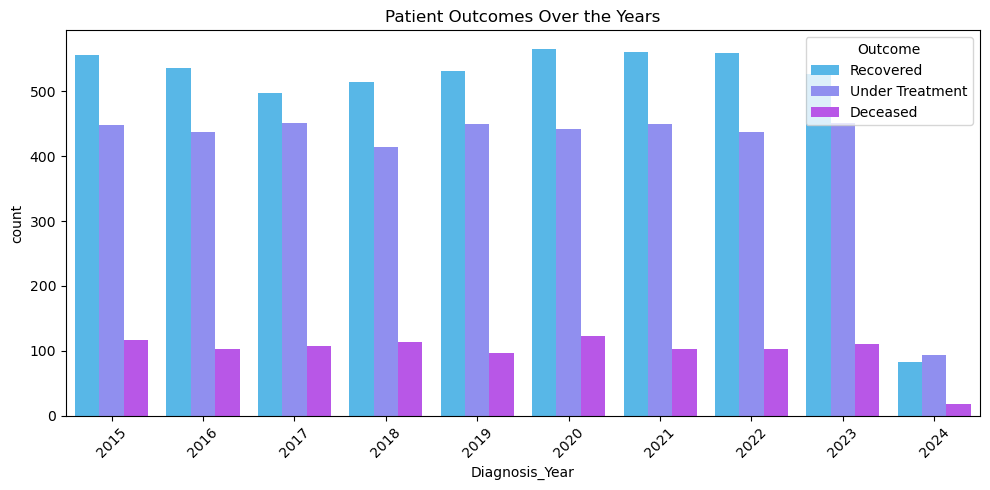


🔎 Total Patient Outcomes:
Recovered: 4931
Under Treatment: 4077
Deceased: 992


In [63]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Diagnosis_Year', hue='Outcome', palette='cool')
plt.title('Patient Outcomes Over the Years')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate and display totals 
print("\n🔎 Total Patient Outcomes:")
totals = df['Outcome'].value_counts()
for outcome, count in totals.items():
    print(f"{outcome}: {count}")


## <span style='color: skyblue;'> Using a Line Chart to show recovery trends over the years </span>

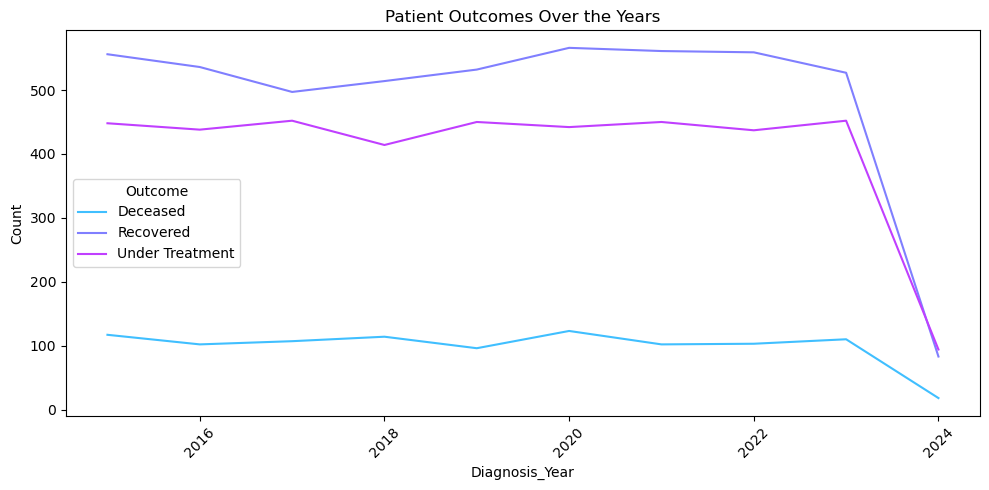


🔎 Total Patient Outcomes:
Recovered: 4931
Under Treatment: 4077
Deceased: 992


In [61]:

# Grouped data for line chart
grouped = df.groupby(['Diagnosis_Year', 'Outcome']).size().reset_index(name='Count')

# Plot the line chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=grouped, x='Diagnosis_Year', y='Count', hue='Outcome', palette='cool')
plt.title('Patient Outcomes Over the Years')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate and display totals 
print("\n🔎 Total Patient Outcomes:")
totals = df['Outcome'].value_counts()
for outcome, count in totals.items():
    print(f"{outcome}: {count}")


## <span style='color: brown;'> Recovery rate by cancer Type </span>

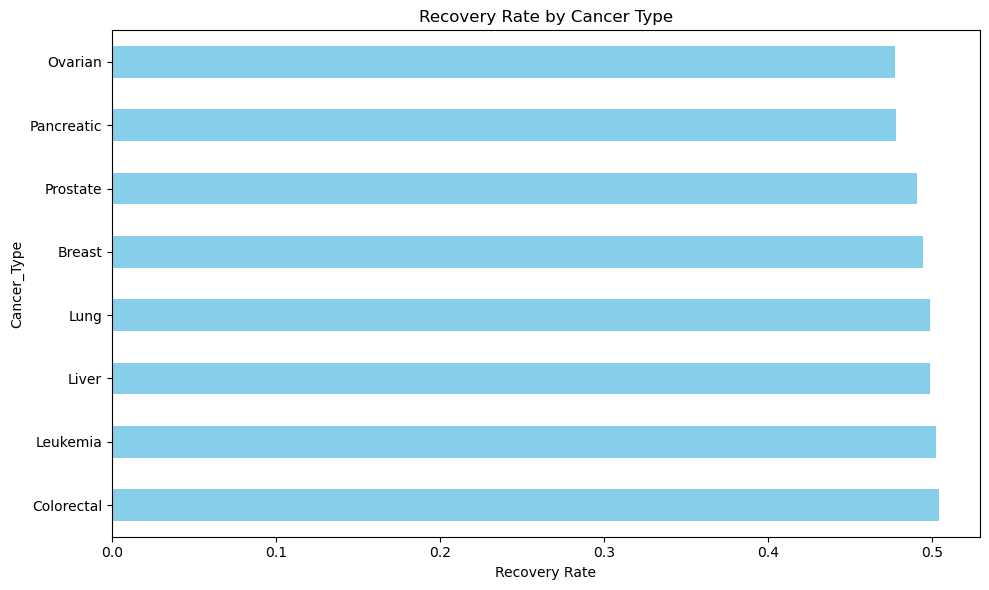

In [93]:
# recovery rate
cancer_outcome = df.groupby(['Cancer_Type', 'Outcome']).size().unstack(fill_value=0)
cancer_outcome['Recovery Rate'] = cancer_outcome.get('Recovered', 0) / cancer_outcome.sum(axis=1)
top_cancer_types = cancer_outcome.sort_values(by='Recovery Rate', ascending=False)

top_cancer_types['Recovery Rate'].plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.xlabel('Recovery Rate')
plt.title('Recovery Rate by Cancer Type')
plt.tight_layout()
plt.show()



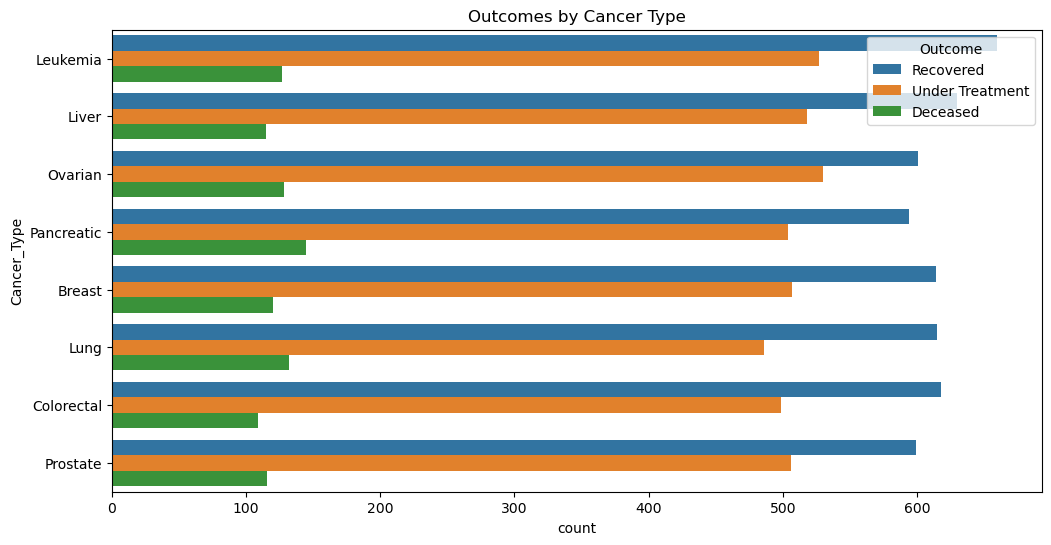


Breast:
  Deceased: 120
  Recovered: 614
  Under Treatment: 507

Colorectal:
  Deceased: 109
  Recovered: 618
  Under Treatment: 499

Leukemia:
  Deceased: 127
  Recovered: 660
  Under Treatment: 527

Liver:
  Deceased: 115
  Recovered: 630
  Under Treatment: 518

Lung:
  Deceased: 132
  Recovered: 615
  Under Treatment: 486

Ovarian:
  Deceased: 128
  Recovered: 601
  Under Treatment: 530

Pancreatic:
  Deceased: 145
  Recovered: 594
  Under Treatment: 504

Prostate:
  Deceased: 116
  Recovered: 599
  Under Treatment: 506


In [85]:
# Recovery rate by cancer type
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Cancer_Type', hue='Outcome', order=df['Cancer_Type'].value_counts().index)
plt.title('Outcomes by Cancer Type')
plt.show()

# Group data by Cancer_Type and Outcome, then count
outcome_counts = df.groupby(['Cancer_Type', 'Outcome']).size().reset_index(name='Count')

# Loop through each cancer type and print formatted summary
for cancer_type in outcome_counts['Cancer_Type'].unique():
    print(f"\n{cancer_type}:")
    subset = outcome_counts[outcome_counts['Cancer_Type'] == cancer_type]
    for _, row in subset.iterrows():
        print(f"  {row['Outcome']}: {row['Count']}")


## <span style='color: magenta;'> Impact of  smoking status on outcome </span>

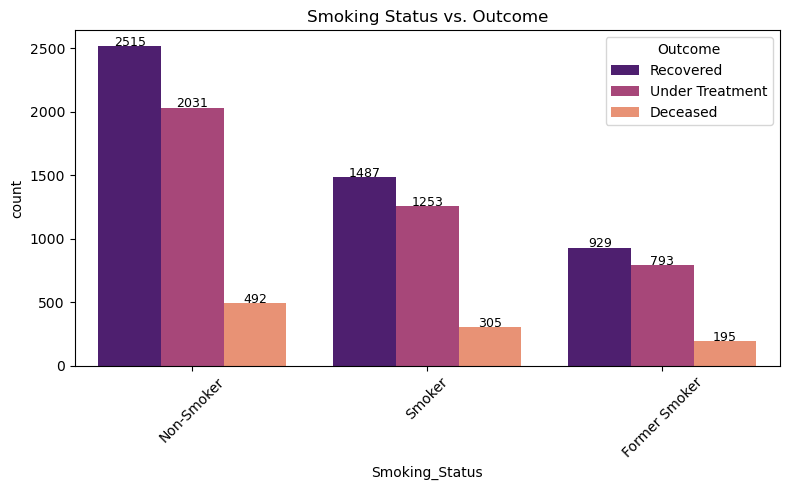

In [252]:
# smoking status on outcome

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Smoking_Status', hue='Outcome', palette='magma')

# Add count labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,  # x-coordinate (centered)
            height + 2,                      # y-coordinate (above bar)
            int(height),                     # count text
            ha="center", fontsize=9
        )

plt.title('Smoking Status vs. Outcome')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## <span style='color: yellow;'> Top 5 most common cancer and recovery rate</span>

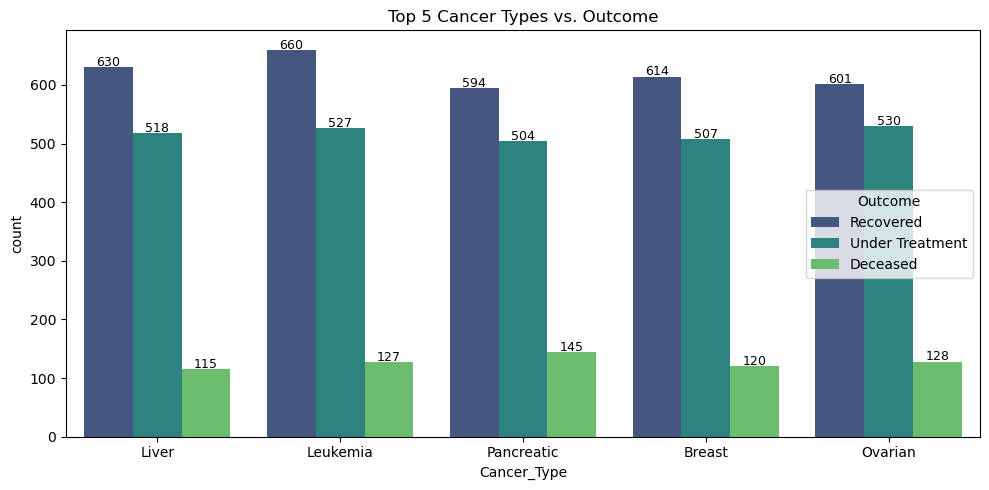

In [138]:

# Filter top 5 cancer types
top5_types = df['Cancer_Type'].value_counts().nlargest(5).index
top5_df = df[df['Cancer_Type'].isin(top5_types)]

# Create the countplot
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=top5_df, x='Cancer_Type', hue='Outcome', palette='viridis')
plt.title('Top 5 Cancer Types vs. Outcome')
plt.tight_layout()

# Add count labels on each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,  # Center of the bar
            height + 2,                      # Just above the top
            int(height),                     # The actual count
            ha="center", fontsize=9
        )

plt.show()


## <span style='color:violet;'> Distributions </span>

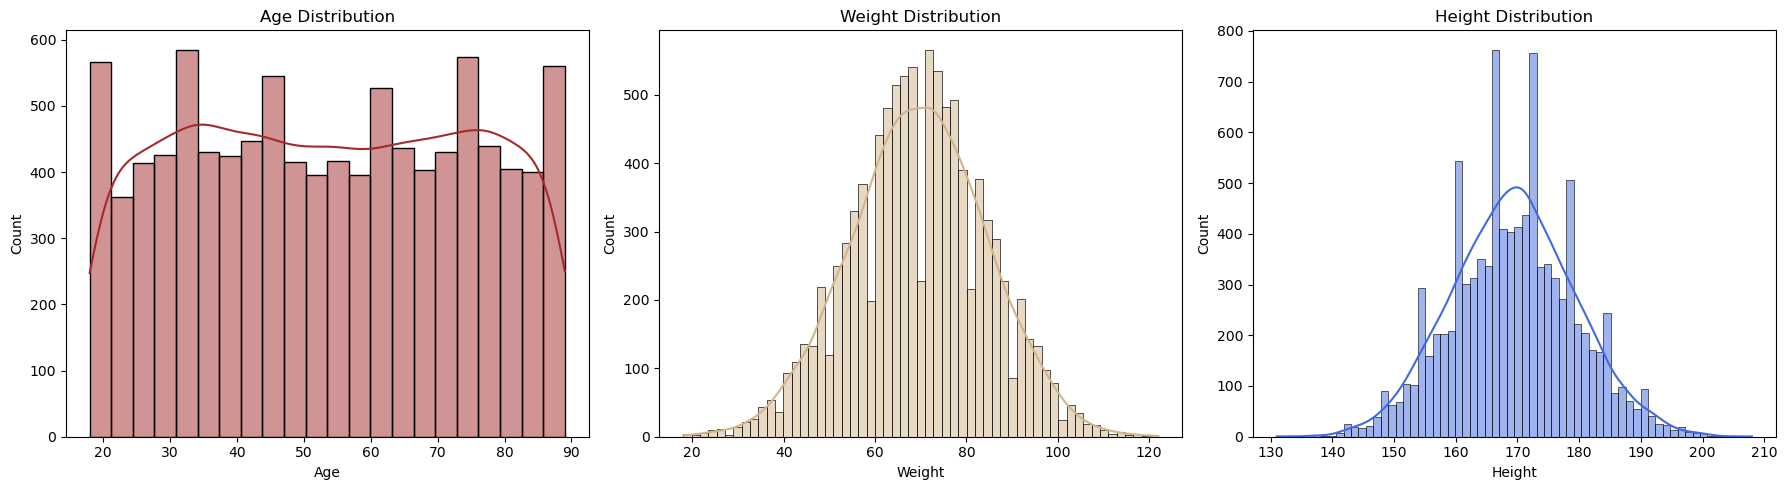

In [115]:
# Distributions
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], kde=True, ax=axs[0], color='brown')
axs[0].set_title('Age Distribution')

sns.histplot(df['Weight'], kde=True, ax=axs[1], color='tan')
axs[1].set_title('Weight Distribution')

sns.histplot(df['Height'], kde=True, ax=axs[2], color='royalblue')
axs[2].set_title('Height Distribution')
plt.tight_layout()
plt.show()

## <span style='color:skyblue;'> Gender and Ethnicity Distribution </span>

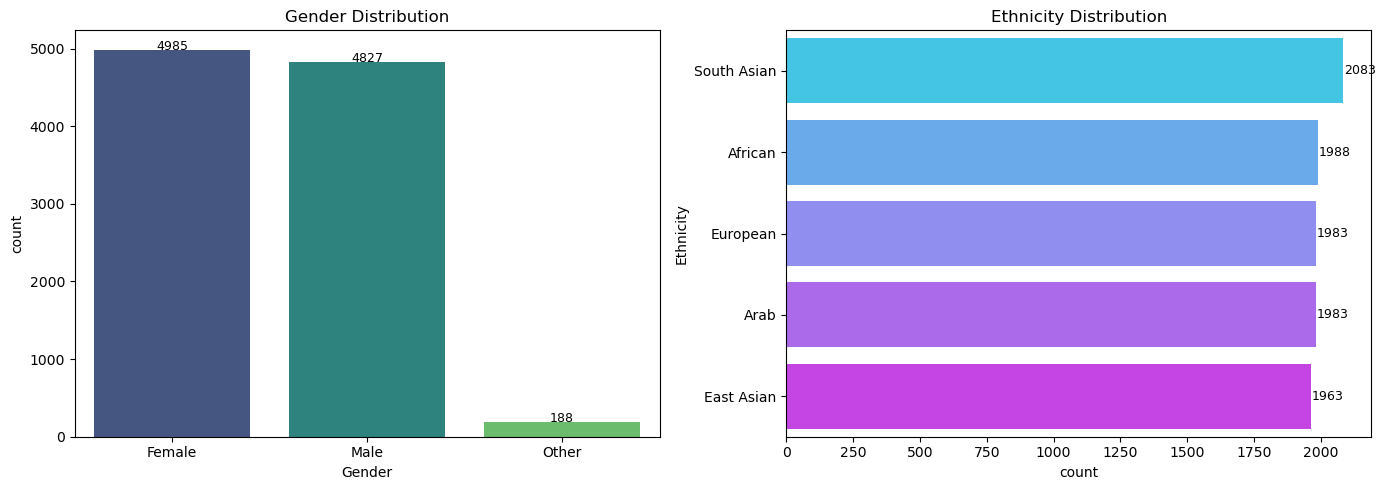

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# === Gender Distribution ===
ax1 = sns.countplot(data=df, x='Gender', palette='viridis', ax=axs[0])
axs[0].set_title('Gender Distribution')

# Annotate bars with counts for Gender
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.text(
            p.get_x() + p.get_width() / 2.,
            height + 2,
            int(height),
            ha='center', fontsize=9
        )

# === Ethnicity Distribution ===
ax2 = sns.countplot(
    data=df,
    y='Ethnicity',
    order=df['Ethnicity'].value_counts().index,
    palette='cool',
    ax=axs[1]
)
axs[1].set_title('Ethnicity Distribution')

# Annotate bars with counts for Ethnicity
for p in ax2.patches:
    width = p.get_width()
    if width > 0:
        ax2.text(
            width + 2,
            p.get_y() + p.get_height() / 2.,
            int(width),
            va='center', fontsize=9
        )

# Final layout
plt.tight_layout()
plt.show()


## <span style='color: purple;'> Cancer types and cancer stage distribution </span>

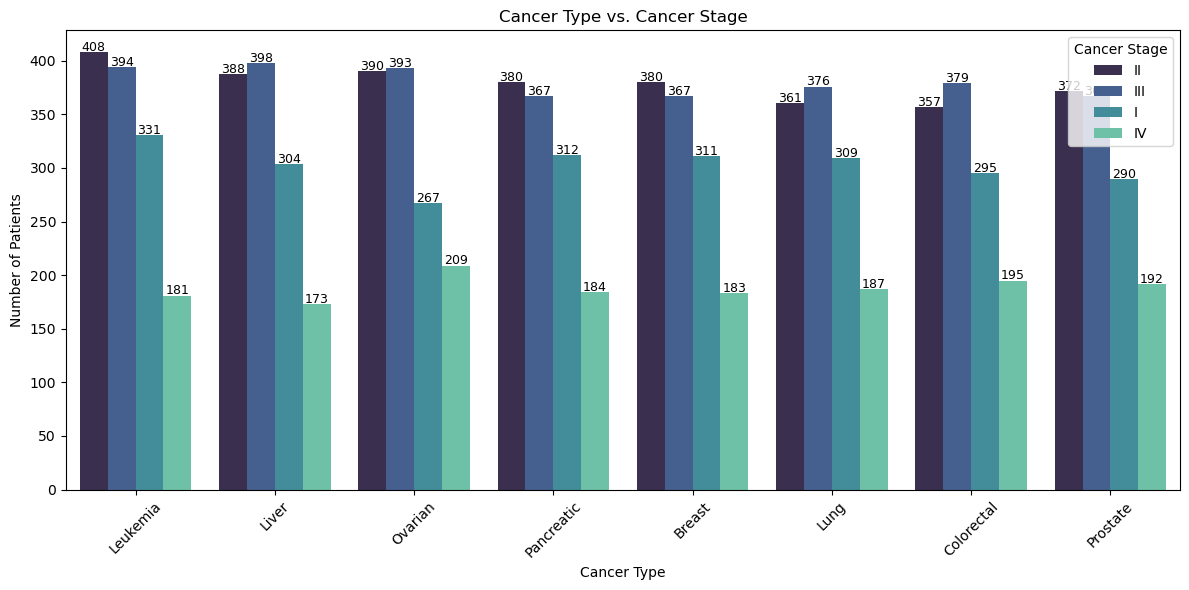

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df,
    x='Cancer_Type',
    hue='Cancer_Stage',
    order=df['Cancer_Type'].value_counts().index,
    palette='mako'
)

# Add count labels to each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 1,
            int(height),
            ha='center',
            fontsize=9
        )

plt.title('Cancer Type vs. Cancer Stage')
plt.xlabel('Cancer Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Cancer Stage')
plt.show()


## <span style='color: red;'> Cancer type distribution among Gender </span>

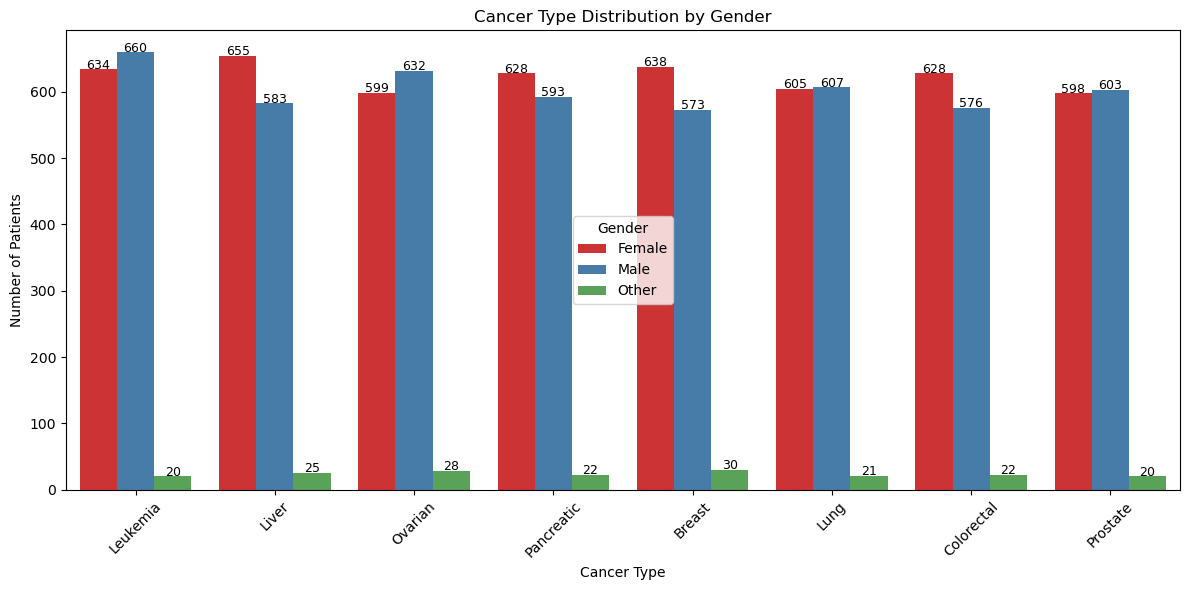

In [136]:

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df,
    x='Cancer_Type',
    hue='Gender',
    order=df['Cancer_Type'].value_counts().index,
    palette='Set1'
)

# Add count labels to each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 1,
            int(height),
            ha='center',
            fontsize=9
        )

plt.title('Cancer Type Distribution by Gender')
plt.xlabel('Cancer Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


## <span style='color:gold;'> Cancer type among different age groups </span> 

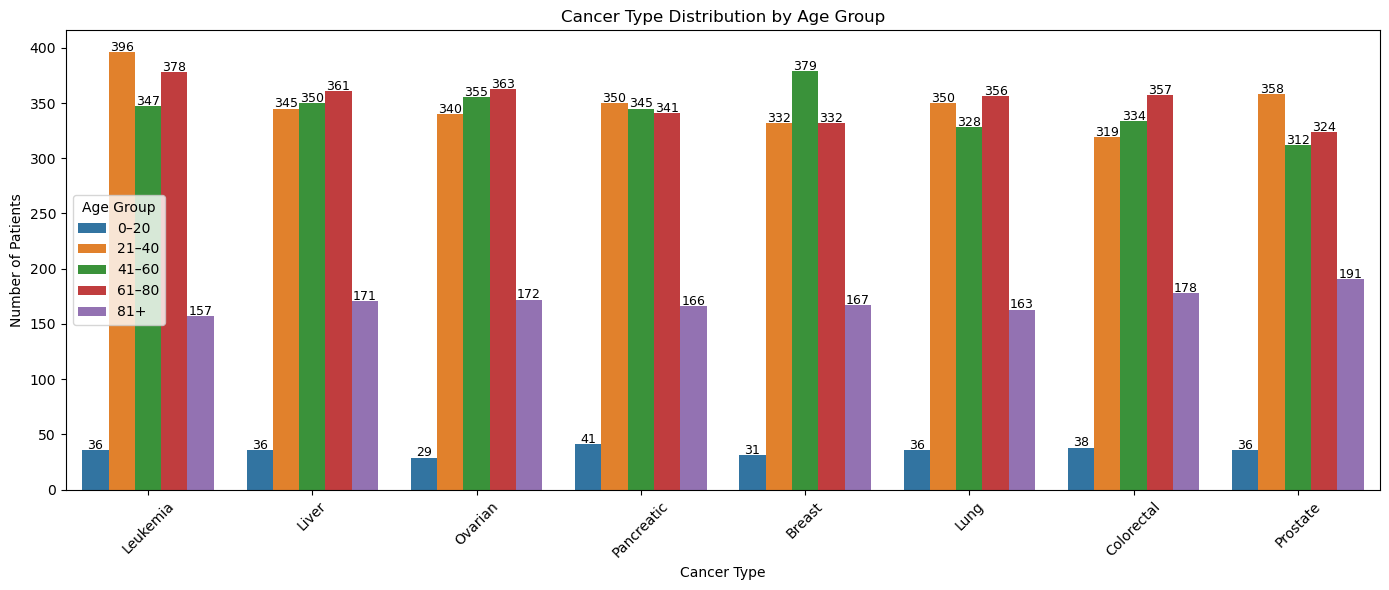

In [146]:

# Step 1: Create Age Groups
bins = [0, 20, 40, 60, 80, 120]
labels = ['0–20', '21–40', '41–60', '61–80', '81+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Step 2: Plot Cancer Type vs Age Group
plt.figure(figsize=(14, 6))
ax = sns.countplot(
    data=df,
    x='Cancer_Type',
    hue='Age_Group',
    order=df['Cancer_Type'].value_counts().index,
    palette='tab10'
)

# Step 3: Add count labels to bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 1,
            int(height),
            ha='center',
            fontsize=9
        )

plt.title('Cancer Type Distribution by Age Group')
plt.xlabel('Cancer Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()


## <span style='color: red;'> Distribution of Treatment type</span>

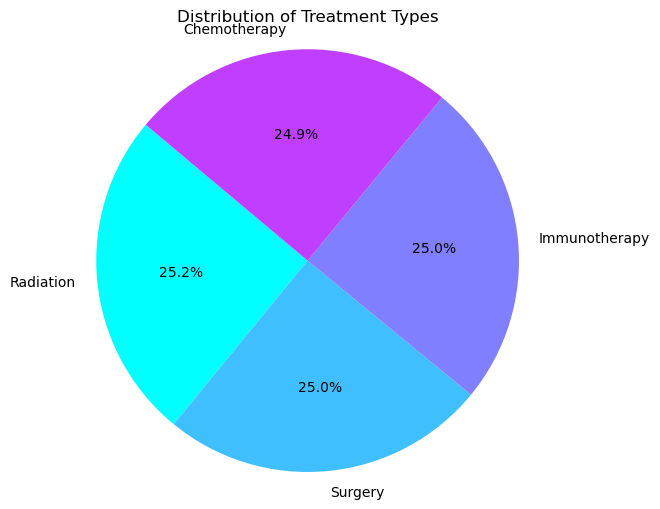

In [177]:
# Count values
counts = df['Treatment_Type'].value_counts()

# Sample colors from the 'cool' colormap based on the number of categories
cmap = plt.cm.cool
colors = [cmap(i / len(counts)) for i in range(len(counts))]

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)
plt.title('Distribution of Treatment Types')
plt.axis('equal')
plt.show()


## <span style='color: forestgreen;'> Outlier Detection and visualization </span>

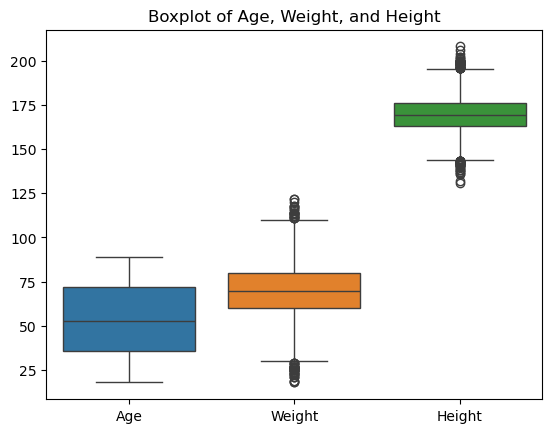

In [148]:
sns.boxplot(data=df[['Age', 'Weight', 'Height']])
plt.title('Boxplot of Age, Weight, and Height')
plt.show()


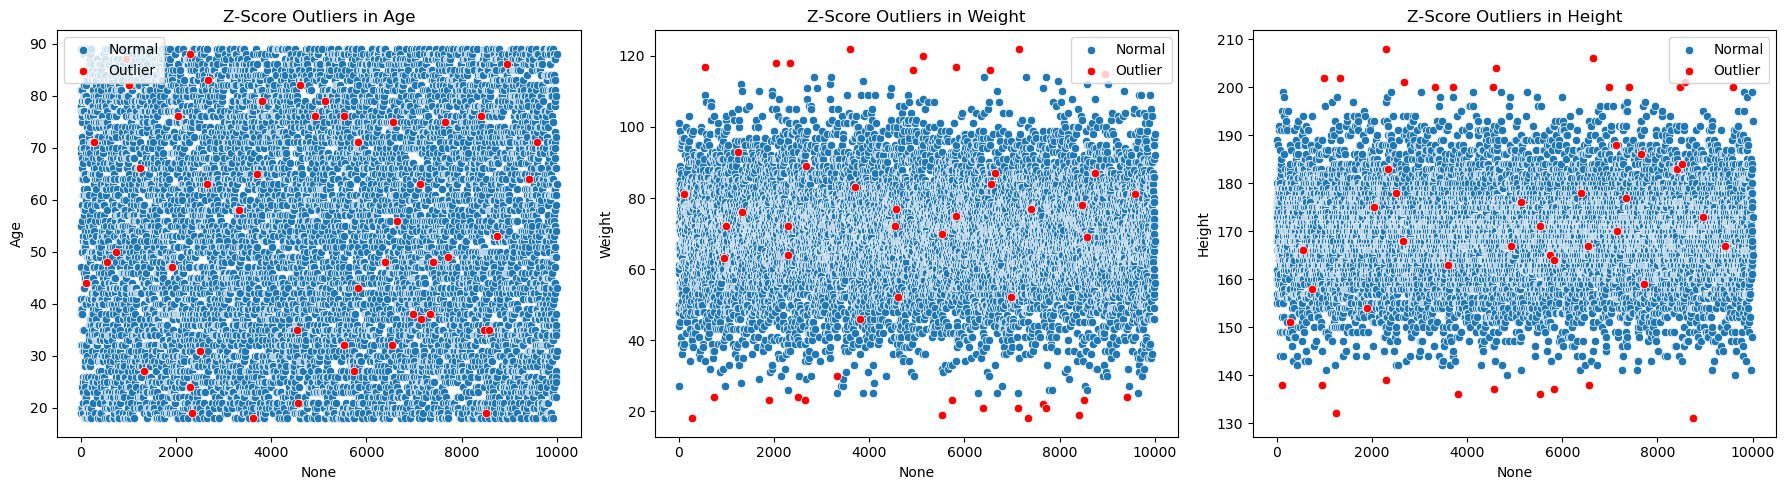

In [150]:
from scipy.stats import zscore

# --- Step 1: Compute Z-scores ---
z_df = df[['Age', 'Weight', 'Height']].apply(zscore)

# --- Step 2: Identify outliers (|z| > 3) ---
threshold = 3
z_outliers = df[(z_df.abs() > threshold).any(axis=1)]

# --- Step 3: Plot each variable with outliers highlighted ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Age plot
sns.scatterplot(x=df.index, y=df['Age'], ax=axs[0], label='Normal')
sns.scatterplot(x=z_outliers.index, y=z_outliers['Age'], ax=axs[0], color='red', label='Outlier')
axs[0].set_title('Z-Score Outliers in Age')
axs[0].set_ylabel('Age')

# Weight plot
sns.scatterplot(x=df.index, y=df['Weight'], ax=axs[1], label='Normal')
sns.scatterplot(x=z_outliers.index, y=z_outliers['Weight'], ax=axs[1], color='red', label='Outlier')
axs[1].set_title('Z-Score Outliers in Weight')
axs[1].set_ylabel('Weight')

# Height plot
sns.scatterplot(x=df.index, y=df['Height'], ax=axs[2], label='Normal')
sns.scatterplot(x=z_outliers.index, y=z_outliers['Height'], ax=axs[2], color='red', label='Outlier')
axs[2].set_title('Z-Score Outliers in Height')
axs[2].set_ylabel('Height')

plt.tight_layout()
plt.show()


## <span style='color: cadetblue;'> PREDICTIVE MODELLING </span>

## <span style='color: lime;'> PREDICTIVE MODELLING USING RANDOM FOREST CLASSIFICATION </span>

Classification Report:
              precision    recall  f1-score   support

           I       0.26      0.20      0.22       301
          II       0.31      0.39      0.35       359
         III       0.32      0.41      0.36       355
          IV       0.20      0.06      0.10       176

    accuracy                           0.30      1191
   macro avg       0.27      0.27      0.26      1191
weighted avg       0.28      0.30      0.28      1191

Confusion Matrix:
[[ 60 122 108  11]
 [ 76 140 127  16]
 [ 64 129 146  16]
 [ 35  61  69  11]]

✅ Model Accuracy (Decimal): 0.2997481108312


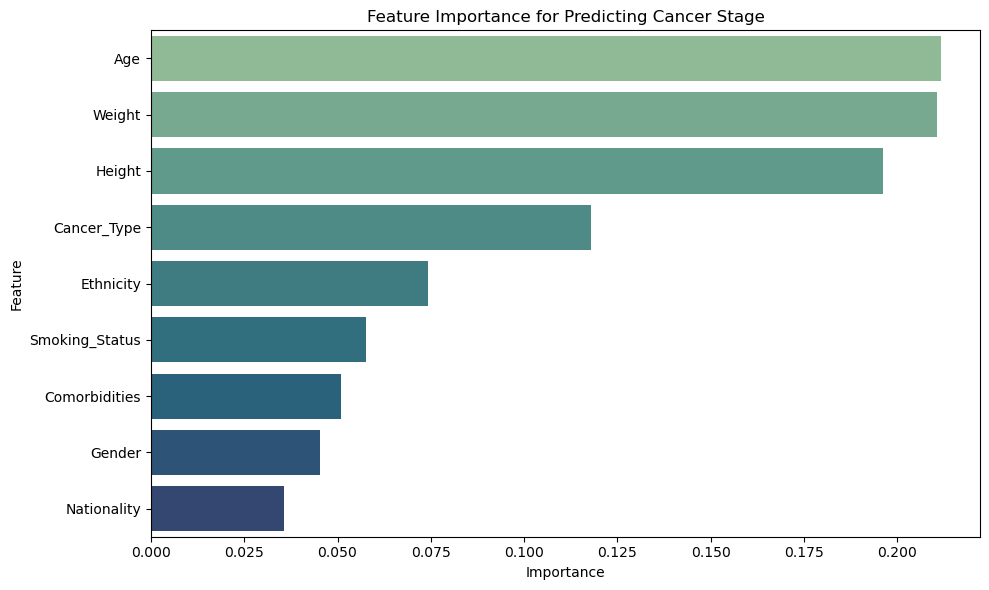

In [239]:


# Select relevant features and drop rows with missing cancer stage
model_df = df[['Age', 'Gender', 'Nationality', 'Ethnicity', 'Smoking_Status', 'Comorbidities',
               'Cancer_Type', 'Weight', 'Height', 'Cancer_Stage']].dropna()

# Encode categorical features
categorical_cols = ['Gender', 'Nationality', 'Ethnicity', 'Smoking_Status', 'Comorbidities', 'Cancer_Type']
encoded_df = model_df.copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col])
    label_encoders[col] = le

# Define features and target
X = encoded_df.drop('Cancer_Stage', axis=1)
y = encoded_df['Cancer_Stage']

# Encode target variable
stage_encoder = LabelEncoder()
y_encoded = stage_encoder.fit_transform(y)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Train a Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=stage_encoder.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy (Decimal): {round(accuracy, 13)}")

# Feature importance
importances = clf.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='crest')
plt.title('Feature Importance for Predicting Cancer Stage')
plt.tight_layout()
plt.show()


C:\Users\Gracious\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:29:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           I       0.27      0.23      0.25       301
          II       0.29      0.35      0.32       359
         III       0.33      0.39      0.36       355
          IV       0.11      0.06      0.08       176

    accuracy                           0.29      1191
   macro avg       0.25      0.26      0.25      1191
weighted avg       0.27      0.29      0.28      1191


Confusion Matrix:
[[ 70 110  96  25]
 [ 77 125 125  32]
 [ 65 124 137  29]
 [ 48  65  52  11]]

✅ XGBoost Model Accuracy (Decimal): 0.3


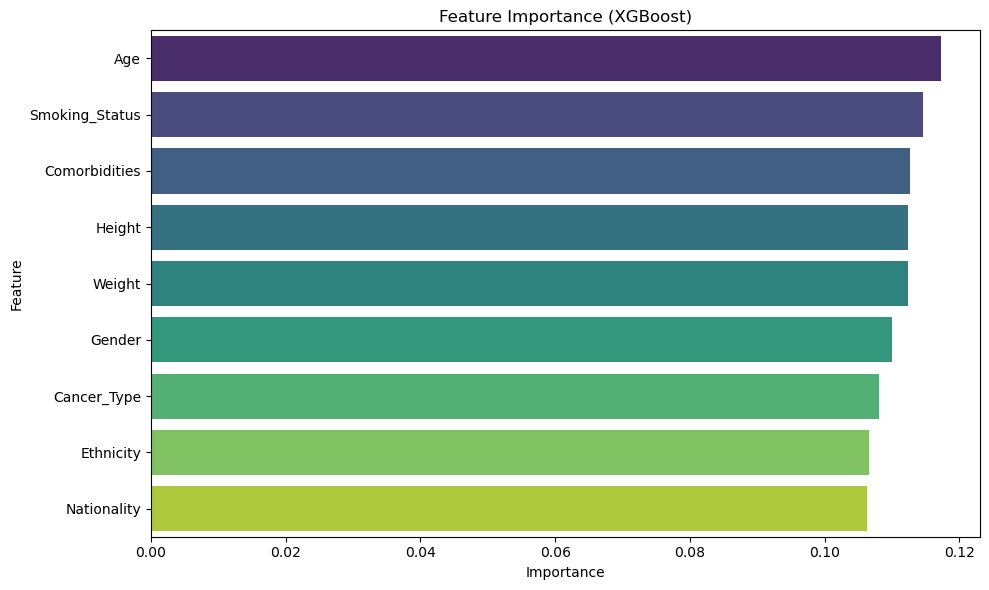

In [208]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Step 1: Prepare Data ---
model_df = df[['Age', 'Gender', 'Nationality', 'Ethnicity', 'Smoking_Status', 'Comorbidities',
               'Cancer_Type', 'Weight', 'Height', 'Cancer_Stage']].dropna()

# Encode categorical features
categorical_cols = ['Gender', 'Nationality', 'Ethnicity', 'Smoking_Status', 'Comorbidities', 'Cancer_Type']
encoded_df = model_df.copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col])
    label_encoders[col] = le

# Define features and target
X = encoded_df.drop('Cancer_Stage', axis=1)
y = encoded_df['Cancer_Stage']

# Encode target variable
stage_encoder = LabelEncoder()
y_encoded = stage_encoder.fit_transform(y)

# --- Step 2: Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# --- Step 3: Train XGBoost Model ---
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y_encoded)), eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train, y_train)

# --- Step 4: Predictions ---
y_pred = xgb_model.predict(X_test)

# --- Step 5: Evaluation ---
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=stage_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ XGBoost Model Accuracy (Decimal): {round(accuracy, 1)}")

# --- Step 6: Feature Importance ---
importances = xgb_model.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()


## <span style='color: cadetblue;'> 🔧 Data Preprocessing and Encoding</span>

In [212]:
# ✅ Select features for clustering (exclude outcome/stage)
cluster_df = df[['Age', 'Gender', 'Nationality', 'Ethnicity', 'Smoking_Status',
                 'Comorbidities', 'Cancer_Type', 'Weight', 'Height']].dropna()

# Encode categorical variables
categorical_cols = ['Gender', 'Nationality', 'Ethnicity', 'Smoking_Status', 'Comorbidities', 'Cancer_Type']
encoded_df = cluster_df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(encoded_df)


## <span style='color: yellow;'> 📈 Elbow Method to Find Optimal k</span>

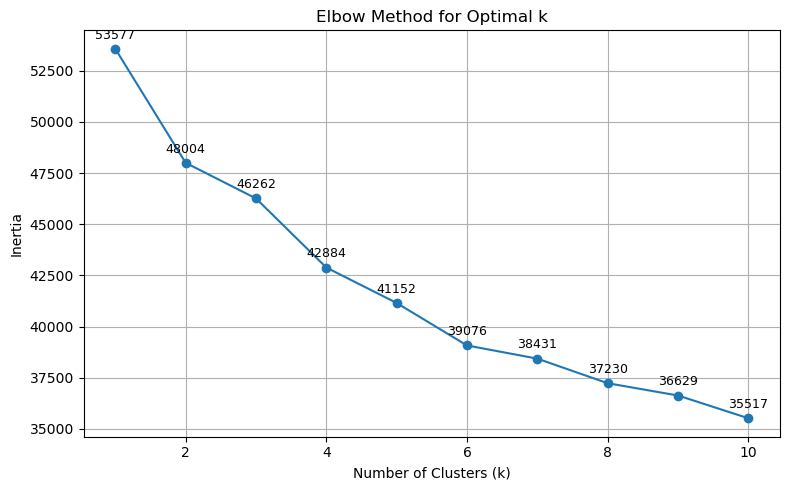

In [216]:
# Elbow Method with annotated markers
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')

# Add inertia values as text labels
for i, val in enumerate(inertia):
    plt.text(k_range[i], val + 500, f"{val:.0f}", ha='center', fontsize=9)

plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
## <span style='color: forestgreen;'> Cluster Profile (Numeric Features) </span>


## <span style='color: brown;'> 📊 Apply KMeans Clustering</span>

In [221]:
# Apply KMeans with optimal k (e.g., k = 3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
cluster_df['Cluster'] = clusters


## <span style='color: forestgreen;'> Visualize Clusters with PCA
 </span>


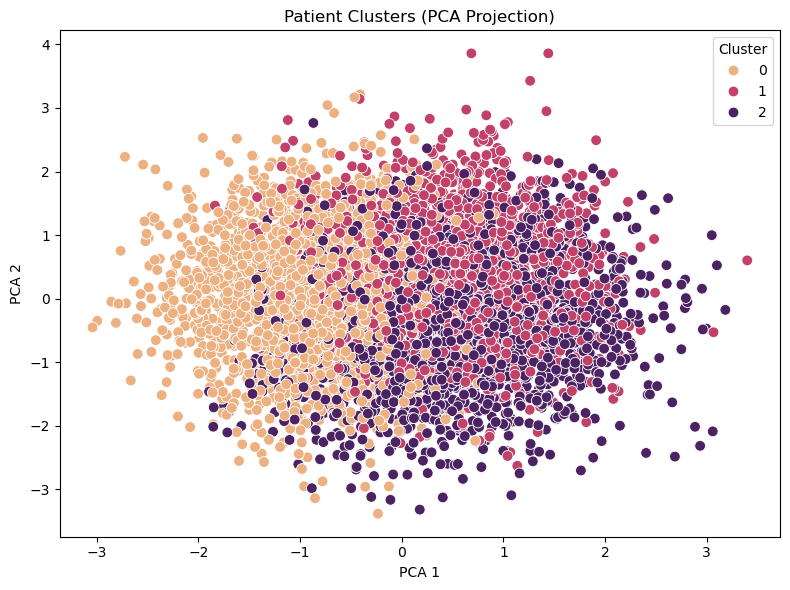

In [231]:
# Use PCA to project into 2D space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='flare', s=60)
plt.title('Patient Clusters (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## <span style='color: forestgreen;'> Cluster Profile (Numeric Features) </span>


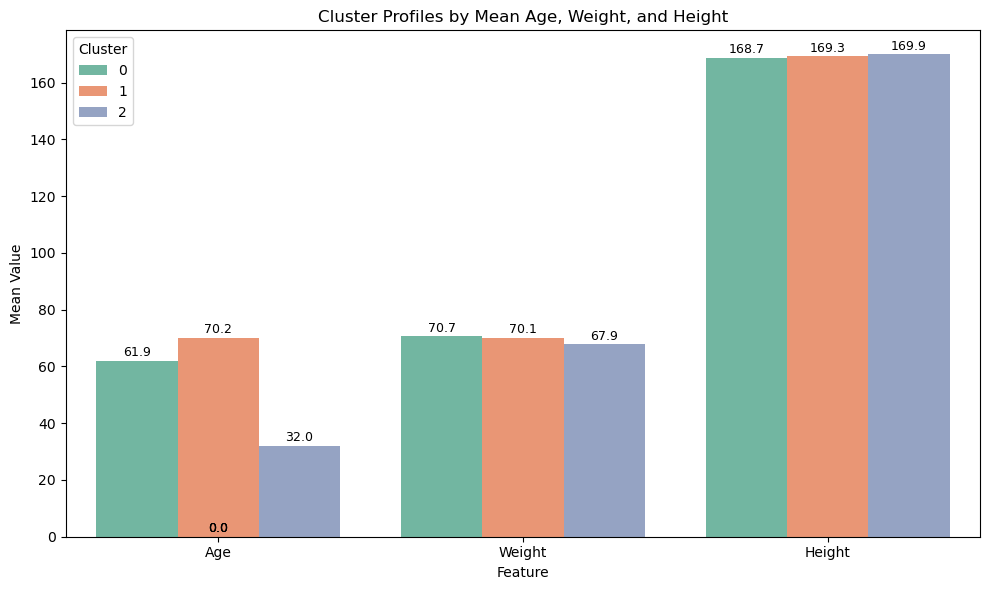

In [229]:
# Plot the cluster profiles with value annotations
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=profile_melted, x='Feature', y='Mean Value', hue='Cluster', palette='Set2')

# Add text labels to each bar
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.5,
            f'{height:.1f}',  # one decimal place
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title('Cluster Profiles by Mean Age, Weight, and Height')
plt.ylabel('Mean Value')
plt.tight_layout()
plt.show()
